<a href="https://colab.research.google.com/github/Rgarlay/Churn-Streamlit/blob/main/DL_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!mkdie -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!kaggle datasets download -dsalader/dogs-vs-cats

import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

/bin/bash: line 1: mkdie: command not found
cp: cannot create regular file '/root/.kaggle/': Not a directory
Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown
... resuming from 833617920 bytes (309273774 bytes left) ...
100% 1.06G/1.06G [00:14<00:00, 22.3MB/s]
100% 1.06G/1.06G [00:14<00:00, 20.9MB/s]


In [ ]:
##We use generators, because working with the entire dataset at once is v. difficult.

In [29]:
import pandas as pd
import numpy as np
import sklearn


/bin/bash: line 1: mkdie: command not found
cp: cannot create regular file '/root/.kaggle/': Not a directory


In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization
from keras.utils import image_dataset_from_directory

In [8]:
train_ds = image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

test_ds = image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [9]:
def Normalize(image,size):
  image = tf.cast(image/255, tf.float32)
  return image,size

In [10]:
train_ds = train_ds.map(Normalize)
validation_ds = test_ds.map(Normalize)

In [50]:
train_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [3]:
from keras import Sequential

In [4]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=( 256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))


model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 254, 254, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 125, 125, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 60, 60, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      14,745,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
from keras.optimizers import Adam

model.compile(optimizer = 'Adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [11]:
history = model.fit(train_ds,epochs=15,validation_data=validation_ds)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 88ms/step - accuracy: 0.6128 - loss: 1.5583 - val_accuracy: 0.6644 - val_loss: 0.6318
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.7577 - loss: 0.5177 - val_accuracy: 0.7104 - val_loss: 0.5930
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.7978 - loss: 0.4383 - val_accuracy: 0.7368 - val_loss: 0.5989
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.8245 - loss: 0.3957 - val_accuracy: 0.7846 - val_loss: 0.6020
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.8615 - loss: 0.3207 - val_accuracy: 0.5782 - val_loss: 1.6561
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.8875 - loss: 0.2603 - val_accuracy: 0.7848 - val_loss: 0.6030
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9263 - loss: 0.1769 - val_accuracy: 0.7698 - val_loss: 0.6626
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 82ms/step - accuracy: 0.9508 - loss: 0.1128 - 

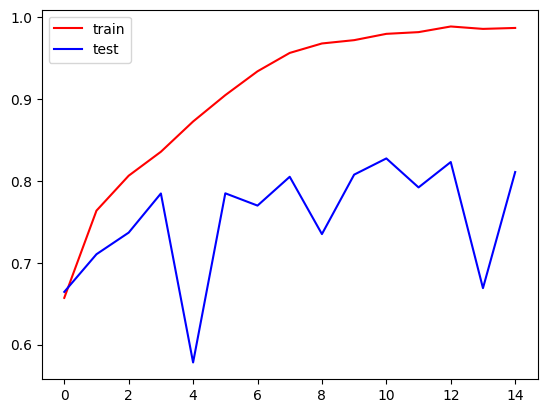

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='test')
plt.legend()
plt.show()

In [17]:
import cv2

imag = cv2.imread('/content/catphoto.jpg')

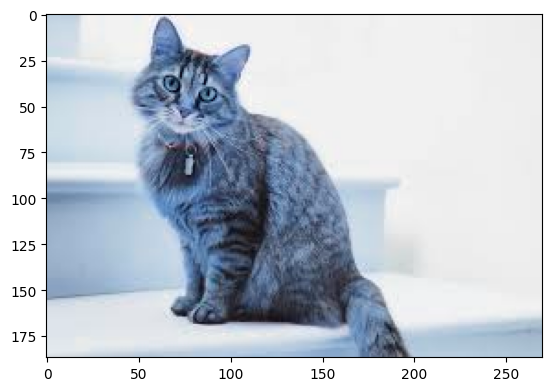

In [19]:
plt.imshow(imag)

In [20]:
imag.shape

(187, 270, 3)

In [21]:
imag = cv2.resize(imag,(256,256))

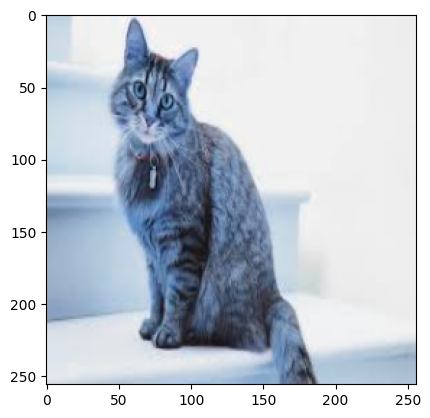

In [22]:
plt.imshow(imag)

In [23]:
test_imput = imag.reshape((1,256,256,3))

In [31]:
result = model.predict(test_imput)
if result == 1:
  print("Its a cat")
else:
  print("its a dawg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Its a cat


In [61]:
def resultoutput(path,model):
  img = cv2.imread(path)
  img = cv2.resize(img,(256,256))
  input = img.reshape((1,256,256,3))
  result = model.predict(input)
  if result == 1:
    output = print("Its a cat")
  else:
    output = print("its a dog")
  return output


In [36]:
path = '/content/2.jpeg'
output = resultoutput(path,model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
its a dawg


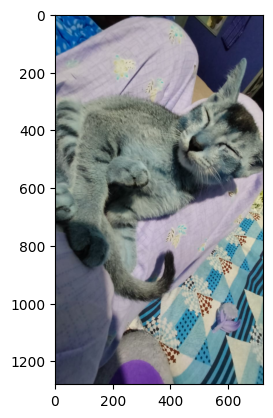

In [60]:
imag = cv2.imread('/content/5.jpg')

plt.imshow(imag)

In [64]:
path = '/content/5.jpg'
output = resultoutput(path,model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
its a dog


In [66]:
history.save('model_name')

AttributeError: 'History' object has no attribute 'save'